In [1]:
import os,sys
%matplotlib inline
import matplotlib.pylab as plt
import pickle
import numpy as np
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi']=300
plt.rcParams['font.family']='sans serif'
plt.rcParams['font.sans-serif']='Arial'
plt.rcParams['pdf.fonttype']=42
# sys.path.append(os.path.expanduser("~/Projects/Github/PyComplexHeatmap/"))
from PyComplexHeatmap import (
    ClusterMapPlotter,HeatmapAnnotation,anno_simple,anno_scatterplot,anno_lineplot,anno_barplot,
    anno_label,anno_boxplot,anno_img,
)
# plt.rcParams

## A quick example

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 19.051388888888887 mm


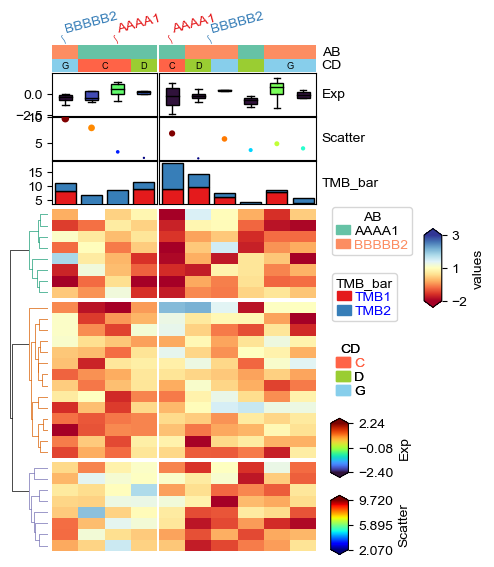

In [2]:
#Generate example dataset (random)
df = pd.DataFrame(['AAAA1'] * 5 + ['BBBBB2'] * 5, columns=['AB'])
df['CD'] = ['C'] * 3 + ['D'] * 3 + ['G'] * 4
df['EF'] = ['E'] * 6 + ['F'] * 2 + ['H'] * 2
df['F'] = np.random.normal(0, 1, 10)
df.index = ['sample' + str(i) for i in range(1, df.shape[0] + 1)]
df_box = pd.DataFrame(np.random.randn(10, 4), columns=['Gene' + str(i) for i in range(1, 5)])
df_box.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_bar = pd.DataFrame(np.random.uniform(0, 10, (10, 2)), columns=['TMB1', 'TMB2'])
df_bar.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_scatter = pd.DataFrame(np.random.uniform(0, 10, 10), columns=['Scatter'])
df_scatter.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_heatmap = pd.DataFrame(np.random.randn(30, 10), columns=['sample' + str(i) for i in range(1, 11)])
df_heatmap.index = ["Fea" + str(i) for i in range(1, df_heatmap.shape[0] + 1)]
df_heatmap.iloc[1, 2] = np.nan

plt.figure(figsize=(4, 6))
col_ha = HeatmapAnnotation(label=anno_label(df.AB, merge=True,rotation=15),
                           AB=anno_simple(df.AB,cmap='Set2'),axis=1,
                           CD=anno_simple(df.CD,add_text=True,colors={'C':'tomato','D':'yellowgreen','G':'skyblue'},
                                            legend_kws={'frameon':False}),
                           Exp=anno_boxplot(df_box, cmap='turbo',height=10),
                           Scatter=anno_scatterplot(df_scatter,height=10), 
                           TMB_bar=anno_barplot(df_bar,height=10,legend_kws={'color_text':False,'labelcolor':'blue'}),
                          rasterized=True)
cm = ClusterMapPlotter(data=df_heatmap, top_annotation=col_ha, col_split=2, row_split=3, col_split_gap=0.5,
                     row_split_gap=1,label='values',row_dendrogram=True,show_rownames=False,show_colnames=False,
                     tree_kws={'row_cmap': 'Dark2'},cmap='RdYlBu',rasterized=True,
                       legend_kws=dict(extend='both',extendfrac=0.1,#boundaries=[-2,0,1,2,3],ticks=[-2,0,1,2,3]
                                      ),
                       legend_vgap=5,legend_hpad=2,legend_vpad=5,vmin=-2,vmax=3,center=1) #
#legend_vgap is the vertical gap between two legends, legend_hpad is the horizonal space between legend and heatmap, legend_vpad
# is the verticall space between the first legend and the top of axes (legend_anchor).
# cm.ax_heatmap.set_axis_off()
plt.savefig("test.pdf",bbox_inches='tight',dpi=300)
plt.show()

## Plotting annotations

### Only plot the row/column annotation

Plotting HeatmapAnnotations


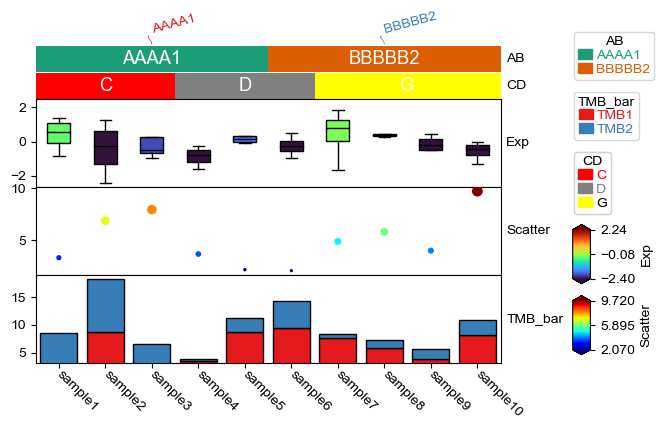

In [3]:
plt.figure(figsize=(6, 4))
col_ha = HeatmapAnnotation(label=anno_label(df.AB, merge=True,rotation=15),
                            AB=anno_simple(df.AB,add_text=True,legend=True,cmap='Dark2'), axis=1,
                            CD=anno_simple(df.CD, colors={'C': 'red', 'D': 'gray', 'G': 'yellow'},
                                           add_text=True,legend=True),
                            Exp=anno_boxplot(df_box, cmap='turbo',legend=True),
                            Scatter=anno_scatterplot(df_scatter), TMB_bar=anno_barplot(df_bar,legend=True),
                           plot=True,legend=True,legend_vgap=3)
col_ha.show_ticklabels(df.index.tolist())
plt.show()

### anno_label:
anno_label is used to add a text label to the annotatin, parameter `merge` control whether to merge the adjacent labels with the same text, if `merge` != True, then, texts would be draw for each columns. We can also annotate the selected rows/cols using `anno_label`. In the following example, we also set `annot=True` to show the float value for each cell,`linewidths=0.05,linecolor='orange'` can be used to control the line and line color for the boarder between cells.

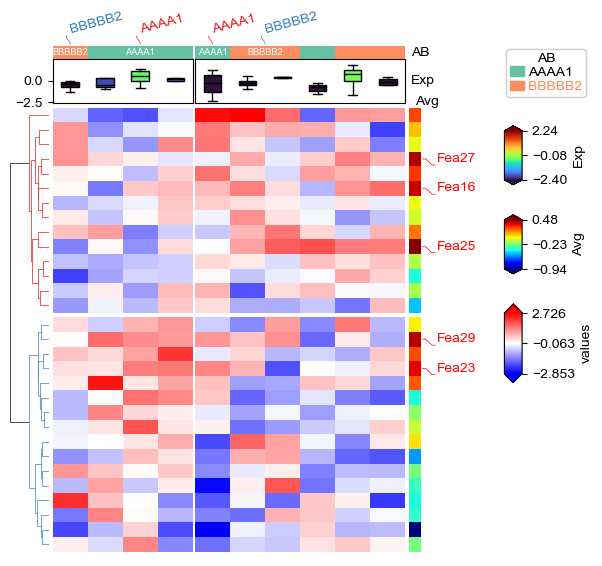

In [4]:
#Annotate the rows with average > 0.3
df_rows = df_heatmap.apply(lambda x:x.name if x.mean() > 0.3 else None,axis=1)
df_rows.name='Selected'

row_ha = HeatmapAnnotation(
            Avg=anno_simple(df_heatmap.mean(axis=1).apply(lambda x:round(x,2)),
                       cmap='jet'), #add_text=True,,text_kws={'rotation':0,'fontsize':10,'color':'black'}
            # Avg=anno_barplot(df_heatmap.mean(axis=1).apply(lambda x:round(x,2)),
            #                height=10,colors='orangered'),
            selected=anno_label(df_rows,colors='red',frac=0.3,rad=0),
            axis=0,verbose=0,label_kws={'rotation':0,'horizontalalignment':'left'})

col_ha = HeatmapAnnotation(
            label=anno_label(df.AB, merge=True,rotation=15),
            AB=anno_simple(df.AB,add_text=True,cmap='Set2'),axis=1,
            Exp=anno_boxplot(df_box, cmap='turbo'),
            verbose=0) #verbose=0 will turn off the log.

plt.figure(figsize=(5.5, 6))
cm = ClusterMapPlotter(
            data=df_heatmap, top_annotation=col_ha,right_annotation=row_ha,
            col_split=2,row_split=2, col_split_gap=0.5,row_split_gap=1,
            label='values',row_dendrogram=True,show_rownames=False,show_colnames=False,
            tree_kws={'row_cmap': 'Set1'},verbose=0,legend_vgap=7,
            #annot=True,linewidths=0.05,linecolor='gold',
            cmap='bwr')
plt.show()

### anno_simple:
anno_simple is to draw simple annotatin, cmap for anno_simple can be either categorical (Set1, Dark2, tab10 et.al) or continnuous (jet, turbo, parula).
Parameter add_text control whether to add text on the annotation, if the color and fontsize in text_kws was not specified, the color and fontsize would be determined automatically, for example, if the background color is deep, then the text color would be white, otherwise the text color would be black. The text color can be changed with parameter text_kws={'color':your_color},for example:

Plotting HeatmapAnnotations


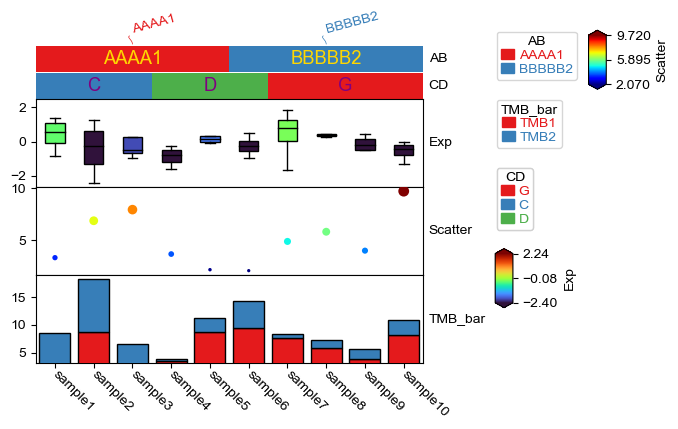

In [5]:
plt.figure(figsize=(5, 4))
col_ha = HeatmapAnnotation(label=anno_label(df.AB, merge=True,rotation=15),
                            AB=anno_simple(df.AB,add_text=True,legend=True,text_kws={'color':'gold'}),
                            CD=anno_simple(df.CD,add_text=True,legend=True,text_kws={'color':'purple'}),
                            Exp=anno_boxplot(df_box, cmap='turbo',legend=True),
                            Scatter=anno_scatterplot(df_scatter), TMB_bar=anno_barplot(df_bar,legend=True),
                           plot=True,legend=True,legend_vgap=5,axis=1)
col_ha.show_ticklabels(df.index.tolist())
plt.show()

### To add a annotation quickly, you just need a dataframe
if df was given, all columns in dataframe df would be treated as a separately anno_simple annotation.

Plotting HeatmapAnnotations


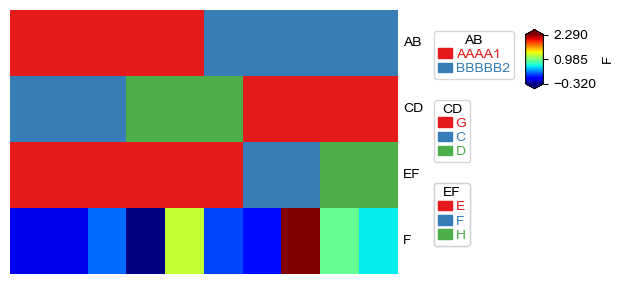

In [6]:
plt.figure(figsize=(5, 3))
col_ha = HeatmapAnnotation(df=df,plot=True,legend=True)
plt.show()

### Plot the figure and legend separately
Sometimes, one only want to plot the figure without legend, or plot the legend in a separated pdf, you can do that by giving the parameter plot_legend=False, and plot the legend in another pdf with row_ha.plot_legends

Plotting HeatmapAnnotations


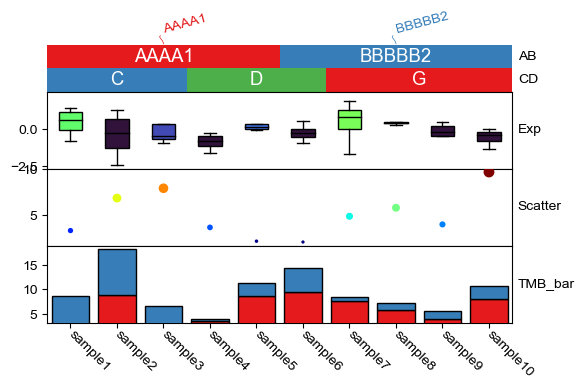

No ax was provided, using plt.gca()


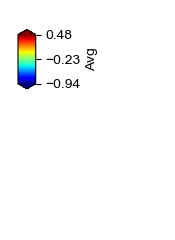

In [7]:
plt.figure(figsize=(6, 4))
col_ha = HeatmapAnnotation(label=anno_label(df.AB, merge=True,rotation=15),
                            AB=anno_simple(df.AB,add_text=True,legend=True), axis=1,
                            CD=anno_simple(df.CD,add_text=True,legend=True),
                            Exp=anno_boxplot(df_box, cmap='turbo',legend=True),
                            Scatter=anno_scatterplot(df_scatter), TMB_bar=anno_barplot(df_bar,legend=True),
                           plot=True,legend=True,plot_legend=False,
                           legend_vgap=5,hgap=0)
col_ha.show_ticklabels(df.index.tolist())
plt.show()

plt.figure(figsize=(2,2.5))
row_ha.plot_legends()
plt.show()

## Top, bottom, left ,right annotations

In [8]:
# Load an example dataset
with open("../data/mammal_array.pkl", 'rb') as f:
    data = pickle.load(f)
df, df_rows, df_cols, col_colors_dict = data

In [9]:
df

,GSM4412025,GSM4412026,GSM4412027,GSM4412028,GSM4412029,GSM4412030,GSM4412031,GSM4412032,GSM4412033,GSM4412034,...,GSM4997945,GSM4997946,GSM4997947,GSM4997948,GSM4997949,GSM4997950,GSM4997951,GSM4997952,GSM4997953,GSM4997954
sheep,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.435033,0.432900,0.446626,0.449123,0.497180,0.515918,0.483706,0.504681,0.529076,0.446443
beluga whale,0.687488,0.694207,0.706525,0.702734,0.687014,0.704003,0.705887,0.693806,0.719417,0.712677,...,0.560381,0.571552,0.610392,0.613619,0.675832,0.668502,0.624820,0.658377,0.702334,0.575034
house mouse,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
vaquita,0.693523,0.702525,0.716792,0.725095,0.711261,0.708651,0.717952,0.705486,0.720915,0.724171,...,0.581862,0.594443,0.628908,0.639457,0.680801,0.707493,0.662338,0.665142,0.751859,0.584952
large flying fox,0.286822,0.269406,0.296796,0.314719,0.305074,0.308419,0.268421,0.297236,0.295019,0.297973,...,0.281684,0.363926,0.367216,0.359392,0.289821,0.257351,0.234301,0.295840,0.249336,0.344848
greater horseshoe bat,0.530606,0.517989,0.520719,0.525855,0.507583,0.511993,0.528107,0.521563,0.542159,0.509526,...,0.735151,0.714805,0.708868,0.738207,0.823604,0.828040,0.823382,0.796882,0.878783,0.693625
little brown bat,0.202525,0.215990,0.238977,0.241872,0.267750,0.236729,0.202384,0.240519,0.251148,0.267257,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
df_rows

,PredictedTaxid,PredictedSpecies,common_names,Family
sheep,9940.0,ovis_aries_rambouillet,sheep,Bovidae
beluga whale,9749.0,delphinapterus_leucas,beluga whale,Monodontidae
house mouse,10090.0,mus_musculus,house mouse,Muridae
vaquita,42100.0,phocoena_sinus,vaquita,Phocoenidae
large flying fox,132908.0,pteropus_vampyrus,large flying fox,Pteropodidae
greater horseshoe,NaN,NaN,NaN,NaN
bat,59479.0,rhinolophus_ferrumequinum,greater horseshoe bat,Rhinolophidae
little brown bat,59463.0,myotis_lucifugus,little brown bat,Vespertilionidae


In [11]:
df_cols

,GSE,Basename,NCBI_scientific_name,taxid,Tissue,Sex,Family,Order,Species,SuccessRate,common_names
GSM4412025,GSE147003,GSM4412025,Ovis aries,9940,Blood,Female,Bovidae,Artiodactyla,Ovis aries,0.765818,sheep
GSM4412026,GSE147003,GSM4412026,Ovis aries,9940,Blood,Female,Bovidae,Artiodactyla,Ovis aries,0.797669,sheep
GSM4412027,GSE147003,GSM4412027,Ovis aries,9940,Blood,Female,Bovidae,Artiodactyla,Ovis aries,0.759256,sheep
GSM4412028,GSE147003,GSM4412028,Ovis aries,9940,Blood,Male,Bovidae,Artiodactyla,Ovis aries,0.749813,sheep
GSM4412029,GSE147003,GSM4412029,Ovis aries,9940,Blood,Female,Bovidae,Artiodactyla,Ovis aries,0.770433,sheep
...,...,...,...,...,...,...,...,...,...,...,...
GSM4997950,GSE164127,GSM4997950,Eptesicus fuscus,29078,Skin,Male,Vespertilionidae,Chiroptera,Eptesicus fuscus,0.660425,big brown bat
GSM4997951,GSE164127,GSM4997951,Eptesicus fuscus,29078,Skin,Male,Vespertilionidae,Chiroptera,Eptesicus fuscus,0.652822,big brown bat
GSM4997952,GSE164127,GSM4997952,Eptesicus fuscus,29078,Skin,Female,Vespertilionidae,Chiroptera,Eptesicus fuscus,0.664746,big brown bat
GSM4997953,GSE164127,GSM4997953,Eptesicus fuscus,29078,Skin,Male,Vespertilionidae,Chiroptera,Eptesicus fuscus,0.650848,big brown bat


In [12]:
col_colors_dict

{'Tissue': {'#A40043': 'Blood',
  '#00E5FF': 'Brain',
  '#00BECC': 'Cerebellum',
  '#B2F8FF': 'Striatum',
  '#6CBF00': 'Liver',
  '#FFCCEE': 'Muscle',
  '#1E9351': 'Skin'}}

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..


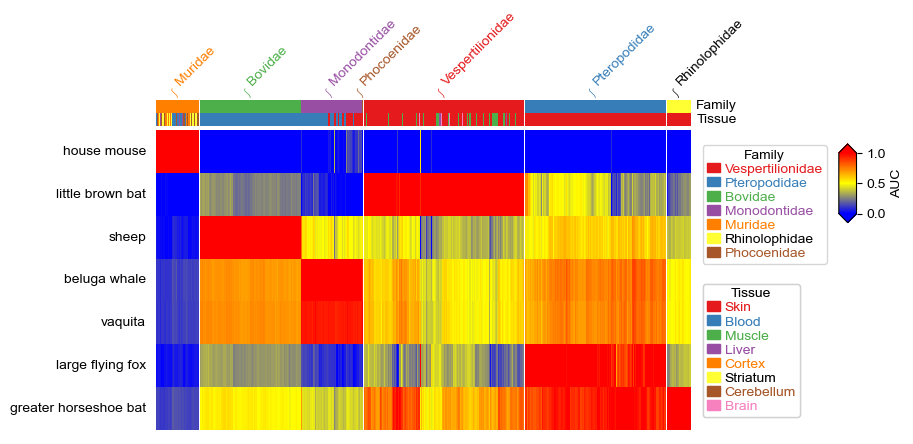

In [13]:
#Put annotations on the top
col_ha = HeatmapAnnotation(label=anno_label(df_cols.Family, merge=True, rotation=45),
                               Family=anno_simple(df_cols.Family, legend=True),
                               Tissue=df_cols.Tissue,label_side='right', axis=1)
plt.figure(figsize=(7, 4))
cm = ClusterMapPlotter(data=df, top_annotation=col_ha,
                       show_rownames=True, show_colnames=False,row_names_side='left',
                       col_split=df_cols.Family, cmap='exp1', label='AUC',
                       rasterized=True, legend=True,legend_anchor='ax_heatmap',legend_width=50)
#legend_pad control the space between heatmap and legend.
#plt.savefig("clustermap.pdf", bbox_inches='tight')
plt.show()

If you have a very long list of legends, the function will automatically increace another column of legend, for example, in the above plot, there are two columns of legends.

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 25.930555555555557 mm


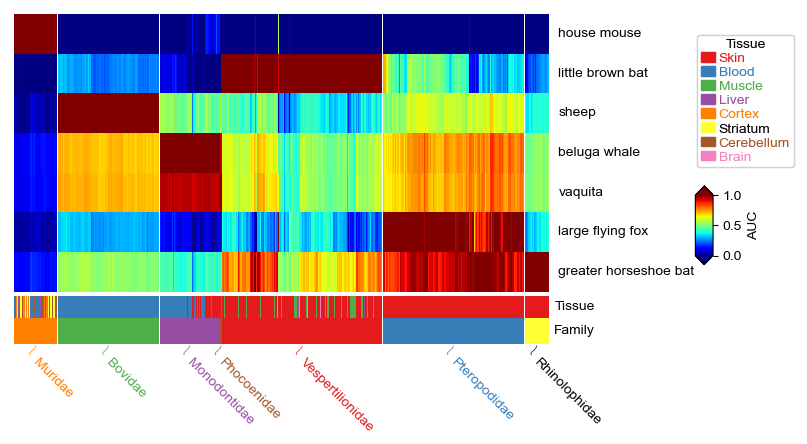

In [14]:
#Put annotations on the bottom
col_ha = HeatmapAnnotation(Tissue=anno_simple(df_cols.Tissue,height=5),
                           Family=anno_simple(df_cols.Family, legend=False,height=6),
                           label=anno_label(df_cols.Family, merge=True,rotation=-45),
                           label_side='right',axis=1)
plt.figure(figsize=(7, 4))
cm = ClusterMapPlotter(data=df, bottom_annotation=col_ha,
                       show_rownames=True, show_colnames=False,row_names_side='right',
                       col_split=df_cols.Family, cmap='jet', label='AUC',
                       rasterized=True, legend=True)
plt.show()

If you want to put the columns annotations on the bottom, then you need to **change the order of HeatmapAnnotation**, `anno_label` should be the **last one** and `anno_label(df_cols.Family)` should be the second last one. When the columns annotation is on the top, the `rotation` of the `anno_label` is 45, but when it is on the bottom, <u>rotation should be -45</u> (rotate to the other direction).<br><br>
In addition, you can change the row labels to the right by setting `row_names_side='right'`. It's worth noting that **the gap betwee the heatmap and the legend could be automatically determined by the code** when you set `row_names_side` to the right.<br><br>
The height of the annotation bar could be changed by the parameter `height` (mm) in `anno_simple` or other kinds of annotation functions.

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


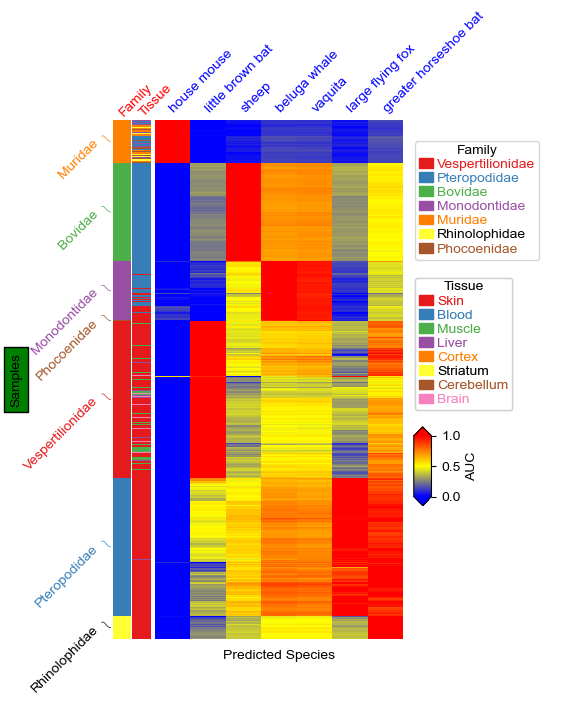

In [15]:
#Put annotations on the left
row_ha = HeatmapAnnotation(label=anno_label(df_cols.Family, merge=True,rotation=45),
                           Family=anno_simple(df_cols.Family, legend=True,height=5),
                           Tissue=anno_simple(df_cols.Tissue,height=5),
                           label_side='top',
                           label_kws={'rotation':45,'rotation_mode':'anchor','color':'red'},
                           axis=0)
plt.figure(figsize=(4, 6))
cm = ClusterMapPlotter(data=df.T,left_annotation=row_ha,
                       show_rownames=False, show_colnames=True,col_names_side='top',
                       row_split=df_cols.Family, row_split_gap=0,
                       cmap='exp1', label='AUC',
                       rasterized=True, legend=True,
                       xticklabels_kws={'labelrotation':45,'labelcolor':'blue'},
                       ylabel="Samples",xlabel="Predicted Species",
                       xlabel_kws=dict(labelpad=0),
                       ylabel_kws=dict(labelpad=50),ylabel_bbox_kws=dict(facecolor='green'))
plt.show()

To put annotation on the left in this example, we tranpose the dataframe by useing df.T and use left_annotation. 
We can put the columns labels on the top by set `col_names_side='top'` and use `xticklabels_kws` to change the rotation and color of the columsn labels.<br><br>
We can also change the rotation and color for the annotation labels (for example, `Family` and `Tissue` in this plot) by set `label_kws={'rotation':45,'rotation_mode':'anchor','color':'red'}`.

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 25.930555555555557 mm


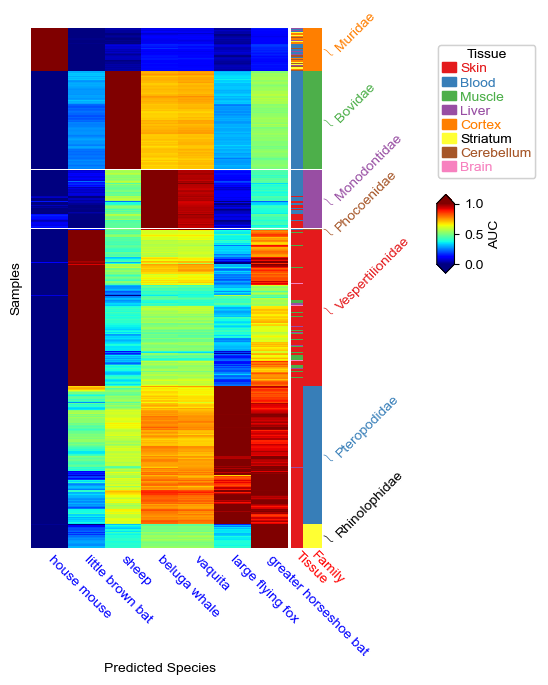

In [16]:
#Put annotation on the right
row_ha = HeatmapAnnotation(Tissue=df_cols.Tissue,
                           Family=anno_simple(df_cols.Family, legend=False,height=5),
                           label=anno_label(df_cols.Family, merge=True,rotation=45),
                           label_side='bottom',
                           label_kws={'rotation':-45,'color':'red'},
                           axis=0)
plt.figure(figsize=(4, 6))
cm = ClusterMapPlotter(data=df.T,right_annotation=row_ha,
                       show_rownames=False, show_colnames=True,col_names_side='bottom',
                       row_split=df_cols.Family, cmap='jet', label='AUC',
                       rasterized=True, legend=True,row_split_gap=0.1,
                       xticklabels_kws={'labelrotation':-45,'labelcolor':'blue'},
                       ylabel="Samples",xlabel="Predicted Species")
#plt.savefig("annotation.pdf", bbox_inches='tight')
plt.show()